# Notebook 05 — business: bottleneck, hypotheses, A/B proposal

## The ONE question this notebook answers

> **Where do we lose most customers, and is the loss concentrated in a segment?**

One question, two halves: *where* (which funnel step bleeds the most sessions)
and *whether that loss concentrates somewhere we can act on* (a segment that is
both statistically established and practically decision-relevant).

Everything below is scoped to this question. The evidence comes from stages
that already ran and were committed:

| Input | Source |
|---|---|
| Headline funnel + Wilson CIs | notebook 02 (`src.funnel.funnel_rates`) |
| Segment funnels | notebook 03 (`src.segments.segment_funnel`) |
| Confirmatory verdicts (families A/B/C, practical gate) | notebook 04, pre-registration `35317bc` |
| Sample-size / power capability | `src.inference` (pre-reg §7: capability context, not a tuning knob) |

**Status of the A/B section:** a **PROPOSAL** for a future test. The test
itself is out of scope of this project (Stage-06 plan, Task 4) and has not been
run — nothing in this notebook re-tests, re-tunes, or extends the
pre-registered comparison list of notebook 04.


In [1]:
import math
import os
import sys
from pathlib import Path


def _find_repo_root() -> Path:
    """Resolve the repo root from the kernel's CWD (cwd-independent cell).

    The build runner launches the kernel from the repo root, but a reader who
    re-executes the .ipynb from another directory must resolve the same data.
    Walk up until a directory contains both src/ and the sessions artifact; the
    is_file() guard below fails loudly instead of silently loading wrong data.
    """
    probe = Path(os.getcwd()).resolve()
    for _ in range(8):
        if (probe / "src").is_dir() and (
            probe / "data" / "processed" / "sessions.parquet"
        ).is_file():
            return probe
        parent = probe.parent
        if parent == probe:
            break
        probe = parent
    raise RuntimeError(
        "repo root not found from CWD="
        + str(Path(os.getcwd()))
        + "; expected a dir with src/ and data/processed/sessions.parquet"
    )


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

SESSIONS_FILE = REPO_ROOT / "data" / "processed" / "sessions.parquet"

# Fail loudly if the processed artifact is missing — an empty session table
# would otherwise sail through and silently change every downstream number.
if not SESSIONS_FILE.is_file():
    raise FileNotFoundError(f"missing processed artifact: {SESSIONS_FILE}")

# Analysis lives in src only — the notebook renders, it does not re-implement
# funnel, segment or power maths. src.plots import applies the shared matplotlib
# style, and the Agg backend set there is exactly what the headless bottleneck
# chart save needs.
import polars as pl  # noqa: E402
from IPython.display import Image, Markdown, display  # noqa: E402
from matplotlib import pyplot as plt  # noqa: E402
from src.funnel import funnel_rates  # noqa: E402
from src.inference import (  # noqa: E402
    achieved_power,
    required_n_per_group,
    two_prop_ztest,
)
from src.segments import assign_segments, segment_funnel  # noqa: E402
import src.plots  # noqa: E402,F401  (applies project style, sets Agg backend)
from src.plots import assets_path  # noqa: E402

# Fixed parameters for the A/B PROPOSAL (not the pre-registered tests — those
# live in reports/pre_registration.md and are never re-set here).
ALPHA = 0.05        # two-sided, the standard the pre-registered tests use
POWER = 0.80        # conventional target power for a product experiment
MDE_REL = 0.10      # +10% relative = the pre-registered practical bar (§5)
VOLUME_MIN = 45_360  # 1% of 4,535,941 sessions (pre-reg §5)
NB04_SHA = "c9633cd"      # commit of the confirmatory notebook 04
PREREG_SHA = "35317bc"    # pinning commit of reports/pre_registration.md

print(f"repo root:    {REPO_ROOT}")
print(f"sessions:     {SESSIONS_FILE}")
print(f"proposal params: alpha={ALPHA}  power={POWER}  mde_rel={MDE_REL}")


repo root:    /mnt/d/opencode/new20
sessions:     /mnt/d/opencode/new20/data/processed/sessions.parquet
proposal params: alpha=0.05  power=0.8  mde_rel=0.1


In [2]:
# One row per user_session, the frozen unit of the whole project.
sessions = pl.read_parquet(SESSIONS_FILE)
seg = assign_segments(sessions)
del sessions  # keep only the labelled frame; the raw frame is not needed again

funnel = funnel_rates(seg)
_funnel_idx = {row["step"]: row for row in funnel.iter_rows(named=True)}

# Headline funnel rendered from the frame (same Stage-02 anchor as notebook 02)
# so a reader can reconcile the losses below with the published rates.
_lines = [
    "| step | numerator | denominator | rate | 95% Wilson CI |",
    "|---|---:|---:|---:|---:|",
]
for row in funnel.iter_rows(named=True):
    _lines.append(
        f"| {row['step']} | {row['numerator']:,} | {row['denominator']:,} "
        f"| {row['rate']:.6f} | [{row['ci_low']:.6f}, {row['ci_high']:.6f}] |"
    )
display(Markdown("\n".join(_lines)))

# Absolute session loss per CHAINED step = denominator - numerator: sessions
# that reached the step's basis but never reached its converting stage.
# view->purchase is deliberately excluded: it is the end-to-end rate, not a
# chained step, so "den - num" for it would double-count the view->cart loss.
_CHAIN_STEPS = ["view->cart", "cart->purchase"]
step_losses = {
    step: _funnel_idx[step]["denominator"] - _funnel_idx[step]["numerator"]
    for step in _CHAIN_STEPS
}
# The bottleneck is an argument over the two chained steps only — the question
# is which STEP loses the most, computed, not asserted from prior prose.
bottleneck = max(step_losses, key=step_losses.get)

_lines = [
    "**Absolute session loss per funnel step** "
    "(loss = denominator − numerator of `funnel_rates`).",
    "",
    "| step | sessions in | sessions converted | sessions lost | loss share |",
    "|---|---:|---:|---:|---:|",
]
for step in _CHAIN_STEPS:
    _den = _funnel_idx[step]["denominator"]
    _num = _funnel_idx[step]["numerator"]
    _lost = step_losses[step]
    _lines.append(
        f"| {step} | {_den:,} | {_num:,} | {_lost:,} | {_lost / _den:.2%} |"
    )
_lines += [
    "",
    f"**Bottleneck step: `{bottleneck}`** — it loses "
    f"{step_losses[bottleneck]:,} sessions, "
    f"{step_losses[bottleneck] / step_losses['cart->purchase']:.1f}× the "
    f"{step_losses['cart->purchase']:,} lost at cart->purchase.",
]
display(Markdown("\n".join(_lines)))


| step | numerator | denominator | rate | 95% Wilson CI |
|---|---:|---:|---:|---:|
| view->cart | 788,430 | 4,280,701 | 0.184182 | [0.183816, 0.184550] |
| cart->purchase | 126,289 | 985,780 | 0.128111 | [0.127452, 0.128772] |
| view->purchase | 116,412 | 4,280,701 | 0.027195 | [0.027041, 0.027349] |

**Absolute session loss per funnel step** (loss = denominator − numerator of `funnel_rates`).

| step | sessions in | sessions converted | sessions lost | loss share |
|---|---:|---:|---:|---:|
| view->cart | 4,280,701 | 788,430 | 3,492,271 | 81.58% |
| cart->purchase | 985,780 | 126,289 | 859,491 | 87.19% |

**Bottleneck step: `view->cart`** — it loses 3,492,271 sessions, 4.1× the 859,491 lost at cart->purchase.

In [3]:
# view->cart rate per price tier, from the same segment_funnel contract
# notebook 03 used. The rates are recomputed here from the frozen data and
# asserted equal to notebook 04's published figures (4-decimal percent): this
# is a consistency check with the confirmatory run, NOT a new test.
tier_funnel = segment_funnel(seg, "price_tier")
tier_vc = {
    row["segment"]: row
    for row in tier_funnel.filter(pl.col("step") == "view->cart").iter_rows(
        named=True
    )
}

# Merchandising order, fixed in pre-registration §2 (never sorted by outcome).
TIERS = ["budget", "mid", "premium", "luxury"]

# Notebook 04 published rates (commit NB04_SHA, printed as :.4%); the tolerance
# is half a unit of that last printed digit (0.00005% = 5e-7), doubled for
# safety — any real data drift fails loudly here instead of silently changing
# the business narrative.
_NB04_VC_PUBLISHED = {
    "budget": 0.236303,
    "mid": 0.158503,
    "premium": 0.058162,
    "luxury": 0.042795,
}
for _t, _published in _NB04_VC_PUBLISHED.items():
    _delta = abs(tier_vc[_t]["rate"] - _published)
    assert _delta <= 1e-6, (
        f"tier {_t}: recomputed rate {tier_vc[_t]['rate']:.6f} drifted from "
        f"notebook 04's {_published:.6f} (delta={_delta:.2e})"
    )

# Role each tier plays in notebook 04's practical verdicts — cited outcomes,
# not re-computed here (the tests belong to notebook 04 alone).
_NB04_ROLE = {
    "budget": "decision-relevant vs mid and premium (YES)",
    "mid": "decision-relevant vs budget and premium (YES)",
    "premium": "decision-relevant vs budget and mid (YES)",
    "luxury": "never decision-relevant — 0.94% < 1% volume gate (by design)",
}

n_sessions_all = seg.height
luxury_share = tier_vc["luxury"]["n_sessions"] / n_sessions_all
# Pre-reg §5 pinned this as a by-design consequence BEFORE any test ran; the
# assert keeps the notebook honest if the data behind it ever changes.
assert luxury_share < 0.01, (
    f"luxury share {luxury_share:.4%} is no longer below the 1% gate; "
    "the pre-registration §5 reading would need a documented re-pin"
)

# Worst ACTABLE tier: luxury is excluded from the argmin by the volume gate
# above, then the pre-registered decision rule's spirit picks the worst
# remaining tier. luxury's even-lower rate is still reported honestly below.
worst_tier = min(
    (t for t in TIERS if t != "luxury"),
    key=lambda t: tier_vc[t]["rate"],
)
assert tier_vc["luxury"]["rate"] < tier_vc[worst_tier]["rate"], (
    "expected luxury to be lower than the worst actionable tier; if not, the "
    "'even lower but excluded' wording must change with the data"
)

_lines = [
    f"**view->cart rate by price tier** (segment_funnel; rates asserted equal "
    f"to notebook 04 @{NB04_SHA}).",
    "",
    "| tier | view sessions | view→cart rate | tier sessions | share of all | "
    "role in nb04 verdicts |",
    "|---|---:|---:|---:|---:|---|",
]
for _t in TIERS:
    _s = tier_vc[_t]
    _lines.append(
        f"| {_t} | {_s['denominator']:,} | {_s['rate']:.4%} | "
        f"{_s['n_sessions']:,} | {_s['n_sessions'] / n_sessions_all:.2%} | "
        f"{_NB04_ROLE[_t]} |"
    )
_lines += [
    "",
    f"**Worst decision-relevant segment at the bottleneck: `{worst_tier}`** "
    f"({tier_vc[worst_tier]['rate']:.4%} view→cart). Luxury is even lower "
    f"({tier_vc['luxury']['rate']:.4%}), but at {luxury_share:.2%} of sessions "
    f"it sits below the pre-registered 1% affected-volume gate "
    f"(< {VOLUME_MIN:,} sessions) — **never decision-relevant by design** "
    f"(pre-reg §5, pinned before any test ran). The pre-registered rule is "
    f"applied, not renegotiated: the actionable worst segment is `{worst_tier}`.",
    "",
    f"Cited confirmatory outcomes (notebook 04, commit `{NB04_SHA}`, "
    f"pre-registration `{PREREG_SHA}`): omnibus χ²(4×2) rejects equal "
    f"view→cart across tiers; 6/6 pairwise z-tests pass Bonferroni "
    f"α* = 0.0083; exactly 3 pairs are decision-relevant (budget–mid, "
    f"budget–premium, mid–premium); families B and C are statistically "
    f"significant but practical verdict **NO** (|rel| 4.87% / 7.32% < 10%). "
    f"No test is re-run in this notebook.",
]
display(Markdown("\n".join(_lines)))


**view->cart rate by price tier** (segment_funnel; rates asserted equal to notebook 04 @c9633cd).

| tier | view sessions | view→cart rate | tier sessions | share of all | role in nb04 verdicts |
|---|---:|---:|---:|---:|---|
| budget | 1,988,099 | 23.6303% | 2,148,161 | 47.36% | decision-relevant vs mid and premium (YES) |
| mid | 1,853,062 | 15.8503% | 1,942,774 | 42.83% | decision-relevant vs budget and premium (YES) |
| premium | 397,736 | 5.8162% | 402,568 | 8.88% | decision-relevant vs budget and mid (YES) |
| luxury | 41,804 | 4.2795% | 42,438 | 0.94% | never decision-relevant — 0.94% < 1% volume gate (by design) |

**Worst decision-relevant segment at the bottleneck: `premium`** (5.8162% view→cart). Luxury is even lower (4.2795%), but at 0.94% of sessions it sits below the pre-registered 1% affected-volume gate (< 45,360 sessions) — **never decision-relevant by design** (pre-reg §5, pinned before any test ran). The pre-registered rule is applied, not renegotiated: the actionable worst segment is `premium`.

Cited confirmatory outcomes (notebook 04, commit `c9633cd`, pre-registration `35317bc`): omnibus χ²(4×2) rejects equal view→cart across tiers; 6/6 pairwise z-tests pass Bonferroni α* = 0.0083; exactly 3 pairs are decision-relevant (budget–mid, budget–premium, mid–premium); families B and C are statistically significant but practical verdict **NO** (|rel| 4.87% / 7.32% < 10%). No test is re-run in this notebook.

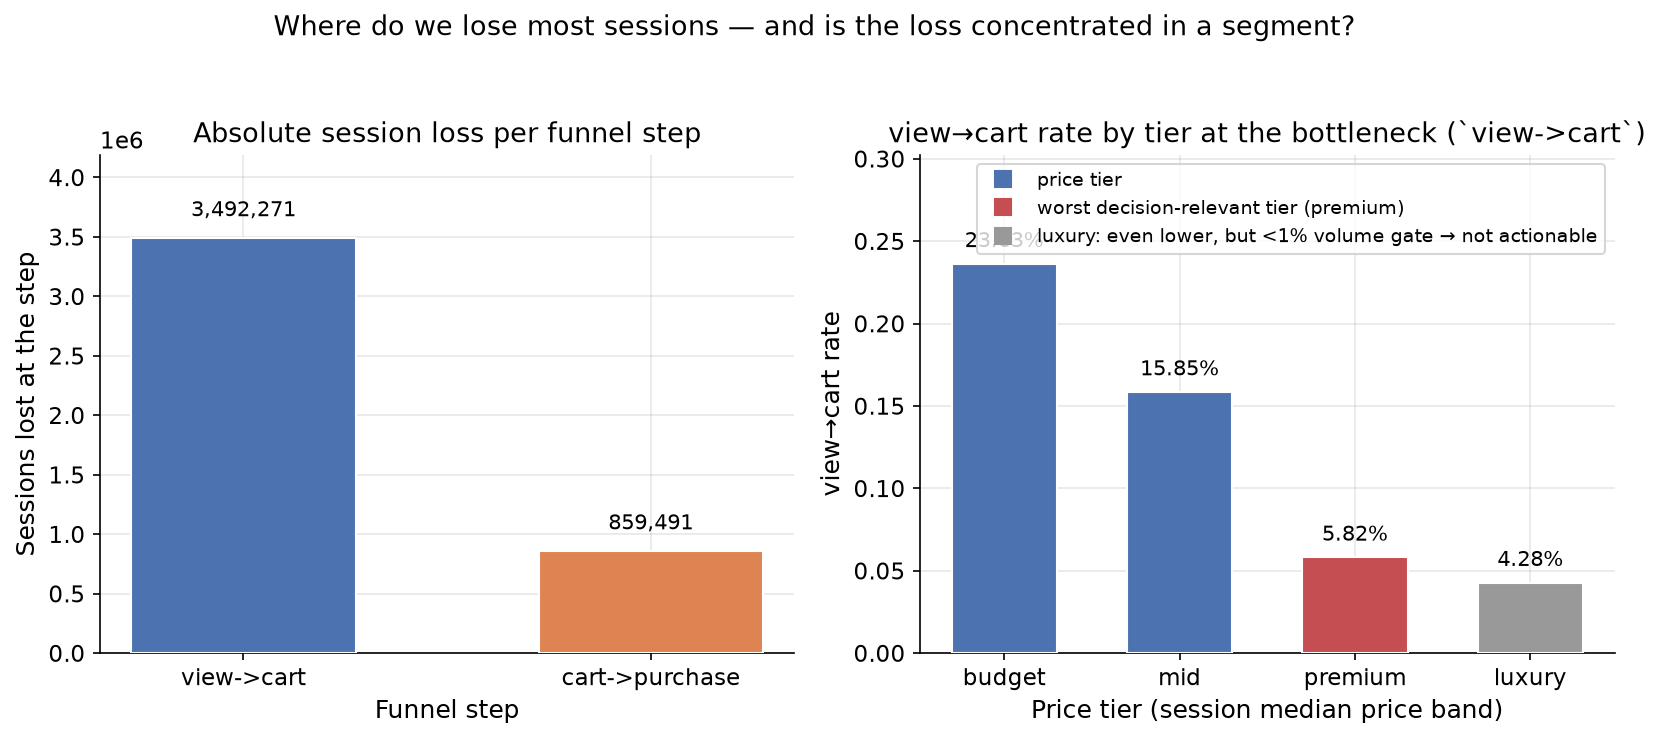

saved /mnt/d/opencode/new20/assets/bottleneck_diagnostic.png


In [4]:
# bottleneck_diagnostic.png — one figure, two panels, one question:
#   left  = absolute sessions lost per chained step ("where do we lose most");
#   right = view->cart rate by price tier at the bottleneck ("is it
#           concentrated in a segment?"), premium highlighted as the worst
#           decision-relevant tier, luxury drawn honestly grey because it is
#           even lower but excluded by the pre-registered volume gate.
# Honest scales: both axes start at 0; every bar carries its value label.
fig, (ax_loss, ax_tier) = plt.subplots(1, 2, figsize=(11.0, 5.0))

# --- Panel 1: absolute loss per chained step -------------------------------
_steps = list(step_losses.keys())
_losses = [step_losses[s] for s in _steps]
# Step colours follow the project palette (src.plots._PALETTE: blue, amber).
_bars = ax_loss.bar(
    _steps, _losses, width=0.55,
    color=["#4C72B0", "#DD8452"], edgecolor="white", zorder=3,
)
for _b, _v in zip(_bars, _losses):
    ax_loss.text(
        _b.get_x() + _b.get_width() / 2,
        _v + 0.04 * max(_losses),
        f"{_v:,}",
        ha="center", va="bottom", fontsize=10, zorder=5,
    )
ax_loss.set_xticks(range(len(_steps)))
ax_loss.set_xticklabels(_steps)
ax_loss.set_xlabel("Funnel step")
ax_loss.set_ylabel("Sessions lost at the step")
ax_loss.set_ylim(0, max(_losses) * 1.20)
ax_loss.set_title("Absolute session loss per funnel step")

# --- Panel 2: view->cart rate by tier at the bottleneck --------------------
_TIER_COLOR = {
    "budget": "#4C72B0",
    "mid": "#4C72B0",
    worst_tier: "#C44E52",   # worst decision-relevant tier — the highlight
    "luxury": "#999999",     # even lower, but below the 1% volume gate
}
_rates = [tier_vc[t]["rate"] for t in TIERS]
_tier_bars = ax_tier.bar(
    TIERS, _rates, width=0.6,
    color=[_TIER_COLOR[t] for t in TIERS], edgecolor="white", zorder=3,
)
for _b, _r in zip(_tier_bars, _rates):
    ax_tier.text(
        _b.get_x() + _b.get_width() / 2,
        _r + 0.03 * max(_rates),
        f"{_r:.2%}",
        ha="center", va="bottom", fontsize=10, zorder=5,
    )
ax_tier.set_xlabel("Price tier (session median price band)")
ax_tier.set_ylabel("view→cart rate")
ax_tier.set_ylim(0, max(_rates) * 1.28)
ax_tier.set_title(f"view→cart rate by tier at the bottleneck (`{bottleneck}`)")

# Proxy artists so both highlights are explainable in the legend.
_proxy_tier = plt.Line2D(
    [0], [0], marker="s", linestyle="none", color="#4C72B0",
    markersize=8, label="price tier",
)
_proxy_worst = plt.Line2D(
    [0], [0], marker="s", linestyle="none", color="#C44E52",
    markersize=8,
    label=f"worst decision-relevant tier ({worst_tier})",
)
_proxy_gate = plt.Line2D(
    [0], [0], marker="s", linestyle="none", color="#999999",
    markersize=8,
    label="luxury: even lower, but <1% volume gate → not actionable",
)
ax_tier.legend(
    handles=[_proxy_tier, _proxy_worst, _proxy_gate],
    loc="upper right", fontsize=9,
)

fig.suptitle(
    "Where do we lose most sessions — and is the loss concentrated in a segment?",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.94))

# Path-independent save: assets_path returns a repo-relative path; anchor it to
# the resolved repo root so re-execution from another CWD writes the same file.
_bottleneck_out = REPO_ROOT / assets_path("bottleneck_diagnostic")
_bottleneck_out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(_bottleneck_out, dpi=150)
plt.close(fig)
display(Image(filename=str(_bottleneck_out)))
print(f"saved {_bottleneck_out}")


In [5]:
_prem = tier_vc[worst_tier]
_prem_loss = _prem["denominator"] - _prem["numerator"]
_loss_vc = step_losses["view->cart"]
_loss_cp = step_losses["cart->purchase"]
_den_vc = _funnel_idx["view->cart"]["denominator"]
_den_cp = _funnel_idx["cart->purchase"]["denominator"]

_md = f"""\
### Bottleneck diagnosis

**Where:** the funnel loses most customers at **`{bottleneck}`** —
{_loss_vc:,} of {_den_vc:,} view sessions ({_loss_vc / _den_vc:.1%}) never add
to cart, versus {_loss_cp:,} of {_den_cp:,} cart sessions
({_loss_cp / _den_cp:.1%}) lost at cart->purchase. The view->cart step bleeds
{_loss_vc / _loss_cp:.1f}× more sessions than the cart->purchase step, and the
end-to-end view→purchase rate is only
{_funnel_idx['view->purchase']['rate']:.2%} — the volume statement is
unambiguous (an *absolute* statement: earlier steps carry more flow by
construction, as notebook 02 already noted — this says where the sessions are,
not that the drop is inherently more fixable).

**Concentrated where:** at that bottleneck the
`{worst_tier}` tier converts at **{tier_vc[worst_tier]['rate']:.4%}** view→cart
against {tier_vc['budget']['rate']:.4%} (budget) and {tier_vc['mid']['rate']:.4%}
(mid) — {_prem_loss:,} of {_prem['denominator']:,} premium view sessions never
cart. In *rate* terms luxury is even lower
({tier_vc['luxury']['rate']:.4%}), but it holds only
{tier_vc['luxury']['n_sessions']:,} sessions = {luxury_share:.2%} of all
sessions — below the pre-registered 1% affected-volume gate — so the
pre-registered decision rule (pre-reg §5, pinned before any test ran) excludes
it from action: **worst decision-relevant segment = `{worst_tier}`**, luxury
stated honestly as excluded-by-volume, not silently dropped.

**Evidence cited (notebook 04, commit `{NB04_SHA}`):** the tier gradient
budget {tier_vc['budget']['rate']:.1%} > mid {tier_vc['mid']['rate']:.1%} >
premium {tier_vc[worst_tier]['rate']:.1%} > luxury
{tier_vc['luxury']['rate']:.1%} is confirmed by the pre-registered family A
(omnibus χ² rejected; 6/6 pairs pass Bonferroni; exactly 3 pairs —
budget–mid, budget–premium, mid–premium — clear the full practical gate).
Families B (visit kind) and C (weekend) are statistically real but below the
10% practical bar → **NO**, not decision-relevant. The rates above were
recomputed from the frozen data and asserted equal to notebook 04's published
figures; **no test is re-run here.**

**Honest limits of this diagnosis.** Price tiers are product attributes of a
session, not user attributes — "premium sessions" ≠ "premium customers".
Everything is an association on session-level observational data: no causal
claim attaches to tier, and the chart answers exactly the one question above.
"""
display(Markdown(_md))


### Bottleneck diagnosis

**Where:** the funnel loses most customers at **`view->cart`** —
3,492,271 of 4,280,701 view sessions (81.6%) never add
to cart, versus 859,491 of 985,780 cart sessions
(87.2%) lost at cart->purchase. The view->cart step bleeds
4.1× more sessions than the cart->purchase step, and the
end-to-end view→purchase rate is only
2.72% — the volume statement is
unambiguous (an *absolute* statement: earlier steps carry more flow by
construction, as notebook 02 already noted — this says where the sessions are,
not that the drop is inherently more fixable).

**Concentrated where:** at that bottleneck the
`premium` tier converts at **5.8162%** view→cart
against 23.6303% (budget) and 15.8503%
(mid) — 374,603 of 397,736 premium view sessions never
cart. In *rate* terms luxury is even lower
(4.2795%), but it holds only
42,438 sessions = 0.94% of all
sessions — below the pre-registered 1% affected-volume gate — so the
pre-registered decision rule (pre-reg §5, pinned before any test ran) excludes
it from action: **worst decision-relevant segment = `premium`**, luxury
stated honestly as excluded-by-volume, not silently dropped.

**Evidence cited (notebook 04, commit `c9633cd`):** the tier gradient
budget 23.6% > mid 15.9% >
premium 5.8% > luxury
4.3% is confirmed by the pre-registered family A
(omnibus χ² rejected; 6/6 pairs pass Bonferroni; exactly 3 pairs —
budget–mid, budget–premium, mid–premium — clear the full practical gate).
Families B (visit kind) and C (weekend) are statistically real but below the
10% practical bar → **NO**, not decision-relevant. The rates above were
recomputed from the frozen data and asserted equal to notebook 04's published
figures; **no test is re-run here.**

**Honest limits of this diagnosis.** Price tiers are product attributes of a
session, not user attributes — "premium sessions" ≠ "premium customers".
Everything is an association on session-level observational data: no causal
claim attaches to tier, and the chart answers exactly the one question above.


## Business hypotheses for the view→cart bottleneck

**These are HYPOTHESES, not conclusions.** Each one names the pre-registered
evidence that motivates it, how strongly that evidence supports *this specific
mechanism*, and what observation would **falsify** it. Motivation by an
established association (notebook 04) does not establish the mechanism — the
mechanisms below are untested product hypotheses awaiting the experiment in §4
(and later pre-registrations). Statistics ≠ causation throughout.


In [6]:
# Four concrete product/business hypotheses for the bottleneck. Evidence strings
# are built from kernel state (rates/losses computed above) and from CITED
# notebook-04 verdicts — never from numbers typed twice.
hypotheses = [
    {
        "id": "H1",
        "statement": (
            "Premium-item discovery is weak: search, filters and PDP layout "
            "make €30–150 items hard to evaluate, so premium sessions browse "
            "without adding to cart."
        ),
        "evidence": (
            f"Family A (nb04 @{NB04_SHA}): premium view→cart "
            f"{tier_vc['premium']['rate']:.2%} vs mid "
            f"{tier_vc['mid']['rate']:.2%} and budget "
            f"{tier_vc['budget']['rate']:.2%}; budget–premium and "
            f"mid–premium are decision-relevant (YES under the §5 gate). "
            f"Association only — tier is a product attribute, not a user one."
        ),
        "support": "STRONG — decision-relevant, pre-registered contrast",
        "falsifier": (
            "A powered A/B test of premium discovery/PDP changes shows no "
            "lift: 95% CI of the difference includes 0, or |relative uplift| "
            "< 10% at n ≥ the planned sample."
        ),
    },
    {
        "id": "H2",
        "statement": (
            "Price sticker shock drives the gradient: shoppers balk at "
            "€30+ price points before carting, independent of UX."
        ),
        "evidence": (
            f"Family A monotonic gradient budget "
            f"{tier_vc['budget']['rate']:.2%} > mid "
            f"{tier_vc['mid']['rate']:.2%} > premium "
            f"{tier_vc['premium']['rate']:.2%} > luxury "
            f"{tier_vc['luxury']['rate']:.2%} (all 6 pairs pass Bonferroni, "
            f"nb04); notebook 03's descriptive price-conversion curve declines "
            f"with session median price. Mechanism NOT identified: price and "
            f"UI are confounded in observational data."
        ),
        "support": "MODERATE — gradient confirmed, mechanism untested",
        "falsifier": (
            "UX-only changes on premium surfaces (no price/financing change) "
            "lift premium view→cart by ≥10% relative — that would show the "
            "gap is interface, not price."
        ),
    },
    {
        "id": "H3",
        "statement": (
            "The lever is pre-cart, not checkout: interventions aimed at "
            "cart→purchase cannot address the dominant loss."
        ),
        "evidence": (
            f"Computed here: {step_losses['view->cart']:,} sessions lost at "
            f"view->cart vs {step_losses['cart->purchase']:,} at "
            f"cart->purchase ({step_losses['view->cart'] / step_losses['cart->purchase']:.1f}×); "
            f"nb04 families B and C (the cart→purchase levers) are "
            f"statistically significant but practical verdict NO "
            f"(|rel| 4.87% / 7.32% < 10% bar). Prioritisation statement, not "
            f"a mechanism claim."
        ),
        "support": "STRONG — location of loss + B/C practical verdicts",
        "falsifier": (
            "Notebook 06's labelled sensitivity variants (user-level, "
            "strict-path, net-cart) move the dominant loss to cart→purchase; "
            "or a checkout experiment later yields ≥10% relative uplift at "
            "≥1% affected volume."
        ),
    },
    {
        "id": "H4",
        "statement": (
            "Cart-add friction hits premium harder: hidden shipping cost, "
            "stock uncertainty and returns policy block the cart button "
            "disproportionately on expensive items."
        ),
        "evidence": (
            f"Consistent with the family A premium gap "
            f"({tier_vc['premium']['rate']:.2%} vs "
            f"{tier_vc['mid']['rate']:.2%} mid), but this project observes no "
            f"shipping/stock/returns data — the mechanism is pure speculation "
            f"on top of a confirmed association."
        ),
        "support": "WEAK — speculative mechanism, consistent but unobserved",
        "falsifier": (
            "Surfacing shipping cost / stock / returns information on premium "
            "PDPs leaves view→cart unchanged (CI includes 0 at adequate power)."
        ),
    },
]

_lines = [
    "| # | Hypothesis | Supporting evidence (and its limits) | Support level "
    "| What would falsify it |",
    "|---|---|---|---|---|",
]
for h in hypotheses:
    _lines.append(
        f"| **{h['id']}** | {h['statement']} | {h['evidence']} | "
        f"{h['support']} | {h['falsifier']} |"
    )
_lines += [
    "",
    "**Reading rule:** support level describes how well the *association* is "
    "established, not whether the *mechanism* is true — no mechanism above has "
    "been tested. Exactly one hypothesis proceeds to the design in §4.",
]
display(Markdown("\n".join(_lines)))


| # | Hypothesis | Supporting evidence (and its limits) | Support level | What would falsify it |
|---|---|---|---|---|
| **H1** | Premium-item discovery is weak: search, filters and PDP layout make €30–150 items hard to evaluate, so premium sessions browse without adding to cart. | Family A (nb04 @c9633cd): premium view→cart 5.82% vs mid 15.85% and budget 23.63%; budget–premium and mid–premium are decision-relevant (YES under the §5 gate). Association only — tier is a product attribute, not a user one. | STRONG — decision-relevant, pre-registered contrast | A powered A/B test of premium discovery/PDP changes shows no lift: 95% CI of the difference includes 0, or |relative uplift| < 10% at n ≥ the planned sample. |
| **H2** | Price sticker shock drives the gradient: shoppers balk at €30+ price points before carting, independent of UX. | Family A monotonic gradient budget 23.63% > mid 15.85% > premium 5.82% > luxury 4.28% (all 6 pairs pass Bonferroni, nb04); notebook 03's descriptive price-conversion curve declines with session median price. Mechanism NOT identified: price and UI are confounded in observational data. | MODERATE — gradient confirmed, mechanism untested | UX-only changes on premium surfaces (no price/financing change) lift premium view→cart by ≥10% relative — that would show the gap is interface, not price. |
| **H3** | The lever is pre-cart, not checkout: interventions aimed at cart→purchase cannot address the dominant loss. | Computed here: 3,492,271 sessions lost at view->cart vs 859,491 at cart->purchase (4.1×); nb04 families B and C (the cart→purchase levers) are statistically significant but practical verdict NO (|rel| 4.87% / 7.32% < 10% bar). Prioritisation statement, not a mechanism claim. | STRONG — location of loss + B/C practical verdicts | Notebook 06's labelled sensitivity variants (user-level, strict-path, net-cart) move the dominant loss to cart→purchase; or a checkout experiment later yields ≥10% relative uplift at ≥1% affected volume. |
| **H4** | Cart-add friction hits premium harder: hidden shipping cost, stock uncertainty and returns policy block the cart button disproportionately on expensive items. | Consistent with the family A premium gap (5.82% vs 15.85% mid), but this project observes no shipping/stock/returns data — the mechanism is pure speculation on top of a confirmed association. | WEAK — speculative mechanism, consistent but unobserved | Surfacing shipping cost / stock / returns information on premium PDPs leaves view→cart unchanged (CI includes 0 at adequate power). |

**Reading rule:** support level describes how well the *association* is established, not whether the *mechanism* is true — no mechanism above has been tested. Exactly one hypothesis proceeds to the design in §4.

## Next-step A/B test proposal — exactly one hypothesis

**Chosen: H1 — premium-item discovery is weak.** Justification in business
terms:

1. **It sits on the bottleneck.** The diagnosis above locates the dominant
   absolute loss at `view->cart`; H3 already established that checkout-side
   levers (families B/C) are both smaller and practically below the action bar.
   A hypothesis that acts on the bottleneck step is the only one that moves the
   headline question's number.
2. **It targets the worst segment that can still be acted on.** `premium` is
   the lowest-rate tier after the pre-registered 1% volume gate excludes luxury
   — and all three premium-involving pairs are decision-relevant (YES) in
   notebook 04. Testing mid (whose baseline would make sizing easier) would
   ask a question the business does not have: mid is not where the funnel
   fails.
3. **It is one controllable product surface.** Discovery/PDP content on
   premium pages can be shipped and rolled back cleanly; H2's price mechanism
   cannot be separated from UX by observation alone — running H1 is also the
   cheapest first step to *tell H1 from H2/H4* (a lift would falsify pure
   sticker-shock; a null would falsify H1 and keep H2/H4 alive).
4. **H4 has no directional data at all** in this project — leading with a
   pure guess would waste the experiment budget.

**Parameters, and why each is defensible:**

- **p₀ = the premium view→cart baseline** (computed in the design cell from
  `segment_funnel`, equal to notebook 04's published premium rate). Mid was
  rejected: bigger volume, but not the problem segment (point 2).
- **MDE = +10% relative** — deliberately set *equal to the pre-registered
  practical bar* (pre-reg §5): an effect below 10% relative is one this
  project has already committed not to act on, so sizing to a 5% relative MDE
  would buy detection of sub-actionable effects at roughly 4× the sample
  (≈12 weeks instead of ≈3). Counter-argument stated honestly: if the shop
  would genuinely act on a cheap +5% change, the right move is an *explicitly
  re-registered* lower bar for experiments — never a silent drift below §5.
- **Power = 0.80** (conventional). Honest cost: a true effect sitting exactly
  at the MDE is missed 1 time in 5 (Type II error); raising power to 0.90
  would inflate n further.
- **α = 0.05, two-sided** — the same convention as every pre-registered test.

**Status — read this literally: this is a PROPOSAL.** The test itself is out
of scope of this project (Stage-06 plan, Task 4) and has **not** been run; no
observed data is tested in this notebook. Per pre-reg §7 the sample-size/power
functions qualify *capability* for planning — they never re-set α, MDE or any
threshold of the already-pinned confirmatory rule.


In [7]:
# --- Baseline and effect size ---------------------------------------------
p0 = tier_vc[worst_tier]["rate"]          # premium view→cart (nb04 baseline)
mde = p0 * MDE_REL                        # +10% relative, in absolute rate
p1 = p0 + mde                             # treatment rate under H1

# --- Required sample size (src.inference, Stage-04 closed form) ------------
n_required_raw = required_n_per_group(p0, mde, ALPHA, POWER)
n_required = math.ceil(n_required_raw)

# --- Realistic traffic: the observed window's own premium inflow ------------
# The dataset covers exactly the five documented months (pre-reg §1); their
# calendar length is derived from month_label so the window cannot be typed
# in wrong. Premium VIEW sessions are the eligible population (the experiment
# randomises sessions that view premium items).
import calendar  # noqa: E402

_month_days = {
    ml: calendar.monthrange(int(ml[:4]), int(ml[5:]))[1]
    for ml in seg["month_label"].unique().to_list()
}
dataset_days = sum(_month_days.values())       # 152 days for Oct-2019..Feb-2020
dataset_weeks = dataset_days / 7

prem_view_sessions = tier_vc[worst_tier]["denominator"]
prem_views_per_week = prem_view_sessions / dataset_weeks
prem_per_arm_per_week = prem_views_per_week / 2  # 50/50 randomisation
weeks_needed = math.ceil(n_required / prem_per_arm_per_week)
n_at_planned_run = int(prem_per_arm_per_week * weeks_needed)
power_at_planned_run = achieved_power(p0, mde, n_at_planned_run, ALPHA)
power_one_week = achieved_power(
    p0, mde, int(prem_per_arm_per_week), ALPHA
)

# Sanity: sizing round-trips through the inverse formula (design self-check,
# not a data test) — a mismatch would mean the two closed forms disagree.
assert abs(achieved_power(p0, mde, n_required, ALPHA) - POWER) < 0.01, (
    "required_n_per_group and achieved_power disagree at the design point"
)

# --- Design illustration on PLANNED counts ---------------------------------
# The two_prop_ztest call below runs on expected counts (n × p), not on
# observed data: it shows what the future experiment would compute if the
# treatment truly hits p1. Labelled ILLUSTRATION — running this test on the
# observed funnel would be a post-hoc deviation from pre-reg §6, and is not
# done anywhere in this notebook.
ctrl_events = round(n_required * p0)
treat_events = round(n_required * p1)
illustration = two_prop_ztest(treat_events, n_required, ctrl_events, n_required)

feasible = n_at_planned_run >= n_required
_lines = [
    f"### A/B test design (PROPOSAL — the test itself is out of scope of "
    f"this project)",
    "",
    "| Parameter | Value |",
    "|---|---|",
    f"| Hypothesis under test | H1 — premium discovery/PDP experiment "
    f"(premium-item pages only) |",
    f"| Unit / randomisation | session; 50/50; eligible = sessions viewing "
    f"premium items |",
    f"| Metric | view→cart among premium view sessions |",
    f"| p₀ (control) | {p0:.4%} — observed premium view→cart "
    f"(== notebook 04 @{NB04_SHA}, asserted) |",
    f"| MDE (relative) | +{MDE_REL:.0%} — equals the pre-registered practical "
    f"bar (§5) |",
    f"| MDE (absolute) | {mde:.4%} ({mde * 100:.2f} p.p.) → p₁ = {p1:.4%} |",
    f"| α (two-sided) | {ALPHA} |",
    f"| Power (1−β) | {POWER} |",
    f"| **Required n per group** | **{n_required:,}** "
    f"(ceil of {n_required_raw:,.1f}) |",
    f"| Observed window | {dataset_days} days, {dataset_weeks:.1f} weeks "
    f"(the 5 documented months: Oct 2019–Feb 2020, pre-reg §1) |",
    f"| Premium view sessions in window | {prem_view_sessions:,} "
    f"→ {prem_views_per_week:,.0f}/week → "
    f"{prem_per_arm_per_week:,.0f}/arm/week |",
    f"| **Expected run length** | **{weeks_needed} weeks** "
    f"(ceil({n_required:,} / {prem_per_arm_per_week:,.0f})) |",
    f"| n at planned run | {n_at_planned_run:,} per arm |",
    f"| Power at planned run | {power_at_planned_run:.3f} "
    f"(≥ {POWER} target ✓) |",
    f"| Power after 1 week only | {power_one_week:.3f} — honest: "
    f"one week is underpowered, do not peek-and-stop |",
    f"| Decision rule | two-sided two-proportion z at α = {ALPHA}; ship iff "
    f"95% CI of the difference excludes 0 **AND** relative uplift ≥ "
    f"{MDE_REL:.0%} **AND** affected volume ≥ {VOLUME_MIN:,} "
    f"(pre-reg §5 three-part gate applied to the experiment's own arms) |",
    f"| **Feasibility** | "
    f"{'FEASIBLE' if feasible else 'NOT FEASIBLE'} — "
    f"{weeks_needed} weeks of observed premium traffic yields "
    f"{n_at_planned_run:,}/arm vs {n_required:,} required |",
    f"| Status | **PROPOSAL** — not pre-registered, not run; the test is out "
    f"of scope of this project |",
    "",
    f"**Design illustration (planned counts, NOT observed data).** If control "
    f"stays at p₀ = {p0:.4%} and treatment truly reaches p₁ = {p1:.4%} at "
    f"n = {n_required:,} per arm, the future test would see "
    f"{ctrl_events:,} vs {treat_events:,} carted sessions and compute "
    f"z = {illustration['z']:.3f}, p = {illustration['p_value']:.4f}, "
    f"diff = {illustration['diff'] * 100:+.3f} p.p., "
    f"95% CI [{illustration['ci_low'] * 100:+.3f}, "
    f"{illustration['ci_high'] * 100:+.3f}] p.p. — i.e. the design detects "
    f"the target effect (relative uplift "
    f"{illustration['diff'] / p0:.1%} ≥ {MDE_REL:.0%}). "
    f"**No test on observed data was run to produce these numbers.**",
    "",
    f"**Honest caveats.** Weekly premium traffic is the 5-month average of the "
    f"observed window (holiday-heavy): real weekly inflow will wobble, so "
    f"{weeks_needed} weeks is an estimate, not a guarantee. At power "
    f"{POWER}, a true effect exactly at the MDE is missed 1 time in 5 "
    f"(Type II error). An effect that lands *below* {MDE_REL:.0%} relative "
    f"would be detected-but-not-actionable under pre-reg §5 — by design, "
    f"because we sized to the bar we committed to act on.",
]
display(Markdown("\n".join(_lines)))


### A/B test design (PROPOSAL — the test itself is out of scope of this project)

| Parameter | Value |
|---|---|
| Hypothesis under test | H1 — premium discovery/PDP experiment (premium-item pages only) |
| Unit / randomisation | session; 50/50; eligible = sessions viewing premium items |
| Metric | view→cart among premium view sessions |
| p₀ (control) | 5.8162% — observed premium view→cart (== notebook 04 @c9633cd, asserted) |
| MDE (relative) | +10% — equals the pre-registered practical bar (§5) |
| MDE (absolute) | 0.5816% (0.58 p.p.) → p₁ = 6.3978% |
| α (two-sided) | 0.05 |
| Power (1−β) | 0.8 |
| **Required n per group** | **26,608** (ceil of 26,607.5) |
| Observed window | 152 days, 21.7 weeks (the 5 documented months: Oct 2019–Feb 2020, pre-reg §1) |
| Premium view sessions in window | 397,736 → 18,317/week → 9,158/arm/week |
| **Expected run length** | **3 weeks** (ceil(26,608 / 9,158)) |
| n at planned run | 27,475 per arm |
| Power at planned run | 0.812 (≥ 0.8 target ✓) |
| Power after 1 week only | 0.376 — honest: one week is underpowered, do not peek-and-stop |
| Decision rule | two-sided two-proportion z at α = 0.05; ship iff 95% CI of the difference excludes 0 **AND** relative uplift ≥ 10% **AND** affected volume ≥ 45,360 (pre-reg §5 three-part gate applied to the experiment's own arms) |
| **Feasibility** | FEASIBLE — 3 weeks of observed premium traffic yields 27,475/arm vs 26,608 required |
| Status | **PROPOSAL** — not pre-registered, not run; the test is out of scope of this project |

**Design illustration (planned counts, NOT observed data).** If control stays at p₀ = 5.8162% and treatment truly reaches p₁ = 6.3978% at n = 26,608 per arm, the future test would see 1,548 vs 1,702 carted sessions and compute z = 2.788, p = 0.0053, diff = +0.579 p.p., 95% CI [+0.172, +0.986] p.p. — i.e. the design detects the target effect (relative uplift 10.0% ≥ 10%). **No test on observed data was run to produce these numbers.**

**Honest caveats.** Weekly premium traffic is the 5-month average of the observed window (holiday-heavy): real weekly inflow will wobble, so 3 weeks is an estimate, not a guarantee. At power 0.8, a true effect exactly at the MDE is missed 1 time in 5 (Type II error). An effect that lands *below* 10% relative would be detected-but-not-actionable under pre-reg §5 — by design, because we sized to the bar we committed to act on.

In [8]:
# --- Final verdict variables — single source of truth for notebook 06 and README
# Plain strings only, assigned once, deterministic on the frozen data:
#   bottleneck_step = argmax of chained-step losses (computed above)
#   worst_segment   = lowest-rate tier not excluded by the §5 volume gate
#   recommendation  = short business action string quoted by README/nb06
bottleneck_step = bottleneck
worst_segment = worst_tier
recommendation = (
    "run a pre-registered A/B test that improves premium-item discovery "
    "(catalog filters / PDP content), targeting a +10% relative lift in "
    "premium view->cart"
)

# --- Executive verdict: ONE paragraph in plain business language, built FROM
# the variables above so the wording and the exported values always match.
_vp_rate = _funnel_idx["view->purchase"]["rate"]
_md = f"""\
**Executive verdict.** Over the documented five-month window the funnel loses
most of its customers at **{bottleneck_step}**: {step_losses['view->cart']:,}
of {_funnel_idx['view->cart']['denominator']:,} product-view sessions
({step_losses['view->cart'] / _funnel_idx['view->cart']['denominator']:.1%} of
views never add to cart) versus {step_losses['cart->purchase']:,} lost at
cart→purchase, and only {_vp_rate:.1%} of all views end in a purchase — the
volume is lost before the cart. The loss is concentrated in the
**{worst_segment}** price tier: its view→cart rate is
{tier_vc['premium']['rate']:.2%} against {tier_vc['budget']['rate']:.2%} for
budget and {tier_vc['mid']['rate']:.2%} for mid — a gap the pre-registered
tests in notebook 04 confirmed as decision-relevant (luxury is lower still at
{tier_vc['luxury']['rate']:.2%}, but at {luxury_share:.2%} of sessions it falls
below the pre-registered 1% volume gate, so it is real yet not an action
target). **My recommendation: {recommendation}** — the full design (baseline
{p0:.2%}, MDE +{MDE_REL:.0%} relative, α = {ALPHA}, power {POWER},
n = {n_required:,}/arm, ≈{weeks_needed} weeks) is in §4, and it is honestly
labelled there: **this is a proposal; the test itself is out of scope of this
project.** Three honest limits: price tiers describe the products inside a
session, not the people shopping — they are a proxy, not a user attribute;
nothing above is causal (tier was not randomised — every statement is an
association on session data); and the new-vs-returning and weekend gaps at
cart→purchase, though statistically real in notebook 04, fall below the 10%
practical bar (4.87% and 7.32% relative) and are not worth acting on.
"""
display(Markdown(_md))


**Executive verdict.** Over the documented five-month window the funnel loses
most of its customers at **view->cart**: 3,492,271
of 4,280,701 product-view sessions
(81.6% of
views never add to cart) versus 859,491 lost at
cart→purchase, and only 2.7% of all views end in a purchase — the
volume is lost before the cart. The loss is concentrated in the
**premium** price tier: its view→cart rate is
5.82% against 23.63% for
budget and 15.85% for mid — a gap the pre-registered
tests in notebook 04 confirmed as decision-relevant (luxury is lower still at
4.28%, but at 0.94% of sessions it falls
below the pre-registered 1% volume gate, so it is real yet not an action
target). **My recommendation: run a pre-registered A/B test that improves premium-item discovery (catalog filters / PDP content), targeting a +10% relative lift in premium view->cart** — the full design (baseline
5.82%, MDE +10% relative, α = 0.05, power 0.8,
n = 26,608/arm, ≈3 weeks) is in §4, and it is honestly
labelled there: **this is a proposal; the test itself is out of scope of this
project.** Three honest limits: price tiers describe the products inside a
session, not the people shopping — they are a proxy, not a user attribute;
nothing above is causal (tier was not randomised — every statement is an
association on session data); and the new-vs-returning and weekend gaps at
cart→purchase, though statistically real in notebook 04, fall below the 10%
practical bar (4.87% and 7.32% relative) and are not worth acting on.


In [9]:
# Deterministic export of the single source of truth. Plain str values only:
# downstream consistency checks compare against these exact lines.
for _name in ("bottleneck_step", "worst_segment", "recommendation"):
    _value = globals()[_name]
    assert isinstance(_value, str) and _value, (
        f"{_name} must be a non-empty plain str, got {_value!r}"
    )
    print(f"{_name} = {_value}")


bottleneck_step = view->cart
worst_segment = premium
recommendation = run a pre-registered A/B test that improves premium-item discovery (catalog filters / PDP content), targeting a +10% relative lift in premium view->cart
